In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  

In [31]:
import urllib.request
import urllib.error
import json
ROLL_NUMBER = 2025201022
index = 0
dataset = []
while True:
    url = f"http://preon.iiit.ac.in:8026/api/data?roll={ROLL_NUMBER}&index={index}"
    try:
        with urllib.request.urlopen(url) as response:
            if response.status == 200:
                data = json.loads(response.read().decode())
                features = data["features"]
                label = data["label"]
                dataset.append((features, label))
                index += 1
    except urllib.error.HTTPError as e:
        if e.code == 404:
            print("Dataset collection finished.")
            break
        else:
            print(f"HTTP Error: {e.code}")
            break
print("Total samples collected:", len(dataset))

Dataset collection finished.
Total samples collected: 2001


In [32]:
df = pd.DataFrame([f + [l] for f,l in dataset])
df.rename(columns={0: "feature1", 1: "feature2", 2: "feature3", 3: "feature4", 4: "feature5", 5: "label"}, inplace=True)
df.head()

,feature1,feature2,feature3,feature4,feature5,label
0,-103.262732,-1.757308,-15.095498,-20.366779,-29.509656,0
1,-24.133228,-4.515910,-33.269067,-12.947363,-2.314955,1
2,-0.171881,-1.617860,-1.370121,-92.981701,-3.126609,1
3,-90.994062,-197.812119,-9.288018,-30.871910,-1.360307,0
4,-2.709175,-3.282887,-3.003855,-13.295747,-4.833484,1


In [ ]:
# helper functions
def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(y_true == y_pred)

# Calculate macro F1 score
def macro_f1_score(y_true, y_pred, n_classes=None):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    if n_classes is None:
        n_classes = int(max(y_true.max(), y_pred.max()) + 1)
    f1s = []
    for c in range(n_classes):
        tp = np.sum((y_true == c) & (y_pred == c))
        fp = np.sum((y_true != c) & (y_pred == c))
        fn = np.sum((y_true == c) & (y_pred != c))
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 0.0 if (precision + recall) == 0 else (2 * precision * recall / (precision + recall))
        f1s.append(f1)
    return float(np.mean(f1s))

# Calculate train test split with random seed 42
def train_test_split(n_samples, test_size=0.2, random_seed=42):
    rng = np.random.default_rng(random_seed)
    idx = np.arange(n_samples)
    rng.shuffle(idx)
    n_test = int(round(n_samples * test_size))
    return idx[n_test:], idx[:n_test]

# Calculate kfold with random seed 42 on training data
def kfold(n_samples, n_splits=5, random_seed=42):
    rng = np.random.default_rng(random_seed)
    idx = np.arange(n_samples)
    rng.shuffle(idx)
    fold_sizes = np.full(n_splits, n_samples // n_splits, dtype=int)
    fold_sizes[: n_samples % n_splits] += 1
    folds = []
    cur = 0
    for fs in fold_sizes:
        start, stop = cur, cur + fs
        val_idx = idx[start:stop]
        tr_idx = np.concatenate([idx[:start], idx[stop:]])
        folds.append((tr_idx, val_idx))
        cur = stop
    return folds

# Inverse normal CDF approximation (for Rank-Gauss)
def norm_ppf(p):
    p = np.asarray(p, dtype=float)
    a = np.array([-39.69683028665376, 220.9460984245205, -275.9285104469687,
                  138.357751867269, -30.66479806614716, 2.506628277459239])
    b = np.array([-54.47609879822406, 161.5858368580409, -155.6989798598866,
                  66.80131188771972, -13.28068155288572])
    c = np.array([-0.007784894002430293, -0.3223964580411365, -2.400758277161838,
                  -2.549732539343734, 4.374664141464968, 2.938163982698783])
    d = np.array([0.007784695709041462, 0.3224671290700398, 2.445134137142996,
                  3.754408661907416])
    plow = 0.02425
    phigh = 1 - plow
    x = np.zeros_like(p)
    low = p < plow
    mid = (p >= plow) & (p <= phigh)
    high = p > phigh
    if np.any(low):
        q = np.sqrt(-2 * np.log(p[low]))
        x[low] = (((((c[0] * q + c[1]) * q + c[2]) * q + c[3]) * q + c[4]) * q + c[5]) / \
                 ((((d[0] * q + d[1]) * q + d[2]) * q + d[3]) * q + 1)
    if np.any(mid):
        q = p[mid] - 0.5
        r = q * q
        x[mid] = (((((a[0] * r + a[1]) * r + a[2]) * r + a[3]) * r + a[4]) * r + a[5]) * q / \
                 (((((b[0] * r + b[1]) * r + b[2]) * r + b[3]) * r + b[4]) * r + 1)
    if np.any(high):
        q = np.sqrt(-2 * np.log(1 - p[high]))
        x[high] = -(((((c[0] * q + c[1]) * q + c[2]) * q + c[3]) * q + c[4]) * q + c[5]) / \
                    ((((d[0] * q + d[1]) * q + d[2]) * q + d[3]) * q + 1)
    return x

In [34]:
# Normalisation methods 1-10
# Min Max Scaling
class MinMaxScalerCustom:
    def fit(self, X_train):
        self.min_ = np.min(X_train, axis=0)
        self.max_ = np.max(X_train, axis=0)
        self.range_ = np.where((self.max_ - self.min_) == 0, 1.0, self.max_ - self.min_)
        return self

    def transform(self, X):
        return (X - self.min_) / self.range_

# Mean Normalisation
class MeanNormalizationCustom:
    def fit(self, X_train):
        self.mean_ = np.mean(X_train, axis=0)
        self.min_ = np.min(X_train, axis=0)
        self.max_ = np.max(X_train, axis=0)
        self.range_ = np.where((self.max_ - self.min_) == 0, 1.0, self.max_ - self.min_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.range_

# Max Absolute Scaler
class MaxAbsScalerCustom:
    def fit(self, X_train):
        self.max_abs_ = np.max(np.abs(X_train), axis=0)
        self.max_abs_ = np.where(self.max_abs_ == 0, 1.0, self.max_abs_)
        return self

    def transform(self, X):
        return X / self.max_abs_

# Decimal Scaling
class DecimalScalingCustom:
    def fit(self, X_train):
        max_abs = np.max(np.abs(X_train), axis=0)
        self.j_ = np.where(max_abs <= 0, 0, np.ceil(np.log10(np.maximum(max_abs, 1e-12))))
        self.scale_ = np.power(10.0, self.j_)
        self.scale_ = np.where(self.scale_ == 0, 1.0, self.scale_)
        return self

    def transform(self, X):
        return X / self.scale_

# Robust Scaler using IQR
class RobustScalerIQRCustom:
    def fit(self, X_train):
        self.q1_ = np.percentile(X_train, 25, axis=0)
        self.q2_ = np.percentile(X_train, 50, axis=0)
        self.q3_ = np.percentile(X_train, 75, axis=0)
        self.iqr_ = np.where((self.q3_ - self.q1_) == 0, 1.0, self.q3_ - self.q1_)
        return self

    def transform(self, X):
        return (X - self.q2_) / self.iqr_

# Z-Score Standardization
class ZScoreStandardizationCustom:
    def fit(self, X_train):
        self.mean_ = np.mean(X_train, axis=0)
        self.std_ = np.std(X_train, axis=0)
        self.std_ = np.where(self.std_ == 0, 1.0, self.std_)
        return self

    def transform(self, X):
        return (X - self.mean_) / self.std_

# Modified Z-score
class ModifiedZScoreCustom:
    def fit(self, X_train):
        self.median_ = np.median(X_train, axis=0)
        mad = np.median(np.abs(X_train - self.median_), axis=0)
        self.mad_ = np.where(mad == 0, 1.0, mad)
        return self

    def transform(self, X):
        return 0.6745 * (X - self.median_) / self.mad_

# Pareto Scaling
class ParetoScalingCustom:
    def fit(self, X_train):
        self.mean_ = np.mean(X_train, axis=0)
        std = np.std(X_train, axis=0)
        self.sqrt_std_ = np.sqrt(np.where(std == 0, 1.0, std))
        return self

    def transform(self, X):
        return (X - self.mean_) / self.sqrt_std_

# Log Transformation
class LogTransformationCustom:
    def fit(self, X_train):
        min_vals = np.min(X_train, axis=0)
        self.shift_ = np.where(min_vals <= 0, -min_vals + 1e-8, 0.0)
        return self

    def transform(self, X):
        return np.log(np.maximum(X + self.shift_, 1e-8))

# Reciprocal Transformation
class ReciprocalTransformationCustom:
    def fit(self, X_train):
        min_vals = np.min(X_train, axis=0)
        self.shift_ = np.where(min_vals <= 0, -min_vals + 1e-8, 0.0)
        return self

    def transform(self, X):
        Xs = X + self.shift_
        Xs = np.where(np.abs(Xs) < 1e-8, 1e-8, Xs)
        return 1.0 / Xs

In [ ]:
# Normalisation methods 11-20 + Raw
# Square Root Transformation
class SquareRootTransformationCustom:
    def fit(self, X_train):
        min_vals = np.min(X_train, axis=0)
        self.shift_ = np.where(min_vals < 0, -min_vals, 0.0)
        return self

    def transform(self, X):
        return np.sqrt(np.maximum(X + self.shift_, 0.0))

# Box-Cox Transformation with lambda=0.5
class BoxCoxLambda05Custom:
    def fit(self, X_train):
        min_vals = np.min(X_train, axis=0)
        self.shift_ = np.where(min_vals <= 0, -min_vals + 1e-8, 0.0)
        self.lam_ = 0.5
        return self

    def transform(self, X):
        Xp = np.maximum(X + self.shift_, 1e-8)
        return (np.power(Xp, self.lam_) - 1.0) / self.lam_

# Yeo-Johnson Transformation with lambda=0.5
class YeoJohnsonLambda05Custom:
    def fit(self, X_train):
        self.lam_ = 0.5
        return self

    def transform(self, X):
        lam = self.lam_
        out = np.zeros_like(X, dtype=float)
        pos = X >= 0
        neg = ~pos
        out[pos] = (np.power(X[pos] + 1.0, lam) - 1.0) / lam
        out[neg] = -((np.power(-X[neg] + 1.0, 2.0 - lam) - 1.0) / (2.0 - lam))
        return out

# Hyperbolic Tangent
class HyperbolicTangentCustom:
    def fit(self, X_train):
        return self

    def transform(self, X):
        return np.tanh(X)

# Sigmoid / Logistic
class SigmoidLogisticCustom:
    def fit(self, X_train):
        return self

    def transform(self, X):
        Xc = np.clip(X, -500, 500)
        return 1.0 / (1.0 + np.exp(-Xc))

# L1 Normalisation
class L1NormalizationCustom:
    def fit(self, X_train):
        return self

    def transform(self, X):
        norms = np.sum(np.abs(X), axis=1, keepdims=True)
        norms = np.where(norms == 0, 1.0, norms)
        return X / norms

# L2 Normalisation
class L2NormalizationCustom:
    def fit(self, X_train):
        return self

    def transform(self, X):
        norms = np.sqrt(np.sum(X * X, axis=1, keepdims=True))
        norms = np.where(norms == 0, 1.0, norms)
        return X / norms

# Softmax Scaling
class SoftmaxScalingCustom:
    def fit(self, X_train):
        return self

    def transform(self, X):
        shifted = X - np.max(X, axis=1, keepdims=True)
        exp_vals = np.exp(shifted)
        sums = np.sum(exp_vals, axis=1, keepdims=True)
        sums = np.where(sums == 0, 1.0, sums)
        return exp_vals / sums

# Quantile Normalisation (Uniform)
class QuantileNormalizationUniformCustom:
    def fit(self, X_train):
        self.sorted_cols_ = [np.sort(X_train[:, j]) for j in range(X_train.shape[1])]
        self.n_ = X_train.shape[0]
        return self

    def transform(self, X):
        out = np.zeros_like(X, dtype=float)
        denom = max(self.n_ - 1, 1)
        for j in range(X.shape[1]):
            ranks = np.searchsorted(self.sorted_cols_[j], X[:, j], side='left')
            out[:, j] = ranks / denom
        return out

# Rank-Gauss Transformation
class RankGaussCustom:
    def fit(self, X_train):
        self.sorted_cols_ = [np.sort(X_train[:, j]) for j in range(X_train.shape[1])]
        self.n_ = X_train.shape[0]
        return self

    def transform(self, X):
        uniform = np.zeros_like(X, dtype=float)
        denom = max(self.n_ - 1, 1)
        for j in range(X.shape[1]):
            ranks = np.searchsorted(self.sorted_cols_[j], X[:, j], side='left')
            uniform[:, j] = ranks / denom

        uniform = np.clip(uniform, 1e-6, 1 - 1e-6)
        return norm_ppf(uniform)

# Raw (No transformation)
class RawIdentity:
    def fit(self, X_train):
        return self

    def transform(self, X):
        return X

# Dictionary of all methods to apply knn on all of them iteratively and compare results
methods = {
    'Raw': RawIdentity,
    'Min-Max Scaling': MinMaxScalerCustom,
    'Mean Normalisation': MeanNormalizationCustom,
    'MaxAbs Scaling': MaxAbsScalerCustom,
    'Decimal Scaling': DecimalScalingCustom,
    'Robust Scaling (IQR)': RobustScalerIQRCustom,
    'Z-Score Standardisation': ZScoreStandardizationCustom,
    'Modified Z-Score': ModifiedZScoreCustom,
    'Pareto Scaling': ParetoScalingCustom,
    'Log Transformation': LogTransformationCustom,
    'Reciprocal Transformation': ReciprocalTransformationCustom,
    'Square Root Transformation': SquareRootTransformationCustom,
    'Box-Cox (lambda=0.5)': BoxCoxLambda05Custom,
    'Yeo-Johnson (lambda=0.5)': YeoJohnsonLambda05Custom,
    'Hyperbolic Tangent': HyperbolicTangentCustom,
    'Sigmoid / Logistic': SigmoidLogisticCustom,
    'L1 Normalisation': L1NormalizationCustom,
    'L2 Normalisation': L2NormalizationCustom,
    'Softmax Scaling': SoftmaxScalingCustom,
    'Quantile Normalisation (Uniform)': QuantileNormalizationUniformCustom,
    'Rank-Gauss': RankGaussCustom,
}
print('Total configurations:', len(methods))  # Raw + 20 methods = 21

Total configurations: 21


In [ ]:
# KNN from scratch + 5-fold Cross Validation Hyperparameter tuning
def neighbor_labels_sorted(X_train, y_train, X_query):
    a2 = np.sum(X_query * X_query, axis=1, keepdims=True)
    b2 = np.sum(X_train * X_train, axis=1)
    d2 = a2 + b2 - 2 * (X_query @ X_train.T)
    d2 = np.maximum(d2, 0.0)
    nn_idx = np.argsort(d2, axis=1)
    return y_train[nn_idx]

# Predict KNN labels from pre-sorted neighbor labels for given k and number of classes
def knn_predict_from_sorted(sorted_neighbor_labels, k, n_classes):
    n_query = sorted_neighbor_labels.shape[0]
    preds = np.zeros(n_query, dtype=int)
    for i in range(n_query):
        votes = np.bincount(sorted_neighbor_labels[i, :k], minlength=n_classes)
        preds[i] = int(np.argmax(votes))
    return preds

# Calculate cross-validation accuracy curve for given normalisation method and return mean accuracy for each k and best k
def cv_accuracy_curve_for_method(X_train, y_train, call_method, n_classes, n_splits=5, max_k=30, random_seed=42):
    folds = kfold(len(X_train), n_splits=n_splits, random_seed=random_seed)
    acc_sum = np.zeros(max_k, dtype=float)
    for tr_idx, val_idx in folds:
        X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
        X_val, y_val = X_train[val_idx], y_train[val_idx]
        normalizer = call_method()
        normalizer.fit(X_tr)
        X_tr_n = normalizer.transform(X_tr)
        X_val_n = normalizer.transform(X_val)
        sorted_labels = neighbor_labels_sorted(X_tr_n, y_tr, X_val_n)
        for k in range(1, max_k + 1):
            y_pred = knn_predict_from_sorted(sorted_labels, k, n_classes)
            acc_sum[k - 1] += accuracy_score(y_val, y_pred)
    acc_mean = acc_sum / n_splits
    best_k = int(np.argmax(acc_mean) + 1)
    return acc_mean, best_k

In [ ]:
# full experiment and master table
label_col = 'label' if 'label' in df.columns else df.columns[-1]
feature_cols = [c for c in df.columns if c != label_col]
X_df = df[feature_cols].apply(pd.to_numeric, errors='coerce')
X_df = X_df.fillna(X_df.median())
X = X_df.to_numpy(dtype=float)
label_cat = pd.Categorical(df[label_col])
y = label_cat.codes.astype(int)
class_names = list(label_cat.categories)
n_classes = len(class_names)

train_idx, test_idx = train_test_split(len(X), test_size=0.2, random_seed=42)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

print(f'Total samples: {len(X)} | Features: {X.shape[1]} | Classes: {n_classes}')
print(f'Train/Test split: {len(train_idx)}/{len(test_idx)}')
max_k = 30
results = []
cv_curves = {}
for method_name, call_method in methods.items():
    cv_curve, best_k = cv_accuracy_curve_for_method(
        X_train, y_train, call_method,
        n_classes=n_classes,
        n_splits=5,
        max_k=max_k,
        random_seed=42
    )
    cv_curves[method_name] = cv_curve
    normalizer = call_method()
    normalizer.fit(X_train)
    X_train_n = normalizer.transform(X_train)
    X_test_n = normalizer.transform(X_test)
    sorted_test_labels = neighbor_labels_sorted(X_train_n, y_train, X_test_n)
    y_pred_test = knn_predict_from_sorted(sorted_test_labels, best_k, n_classes)
    test_acc = accuracy_score(y_test, y_pred_test)
    test_f1 = macro_f1_score(y_test, y_pred_test, n_classes=n_classes)
    results.append({
        'Method Name': method_name,
        'Best k': best_k,
        'Test Accuracy': test_acc,
        'Macro F1-Score': test_f1,
    })
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
results_df['Rank'] = np.arange(1, len(results_df) + 1)
results_df = results_df[['Method Name', 'Best k', 'Test Accuracy', 'Macro F1-Score', 'Rank']]

display(results_df)
print("Accuracy on raw data : ", results_df[results_df['Method Name'] == 'Raw']['Test Accuracy'].values[0])
best_method = results_df.iloc[0]['Method Name']
worst_method = results_df.iloc[-1]['Method Name']
print('Best method:', best_method)
print('Worst method:', worst_method)

Total samples: 2001 | Features: 5 | Classes: 2
Train/Test split: 1601/400


,Method Name,Best k,Test Accuracy,Macro F1-Score,Rank
0,Rank-Gauss,23,0.9825,0.982500,1
1,Quantile Normalisation (Uniform),20,0.9775,0.977500,2
2,Z-Score Standardisation,15,0.9775,0.977500,3
3,Modified Z-Score,13,0.9775,0.977500,4
4,Pareto Scaling,13,0.9775,0.977500,5
5,Box-Cox (lambda=0.5),16,0.9750,0.974999,6
6,Mean Normalisation,4,0.9750,0.974997,7
7,MaxAbs Scaling,4,0.9750,0.974997,8
8,Robust Scaling (IQR),10,0.9750,0.974999,9
9,Log Transformation,4,0.9750,0.974997,10


Accuracy on raw data :  0.97
Best method: Rank-Gauss
Worst method: L2 Normalisation


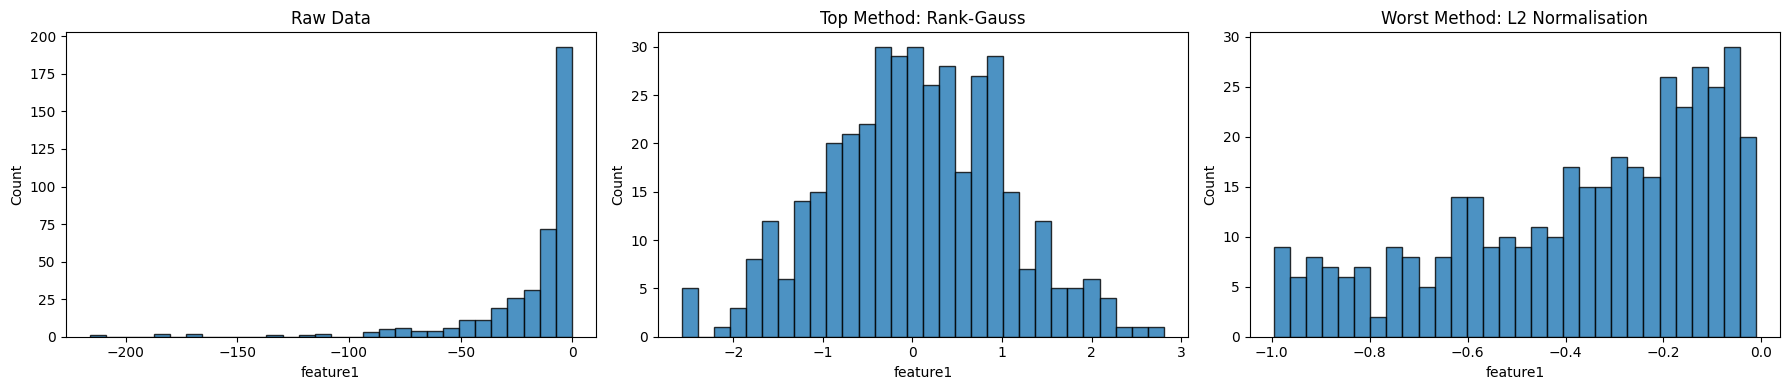

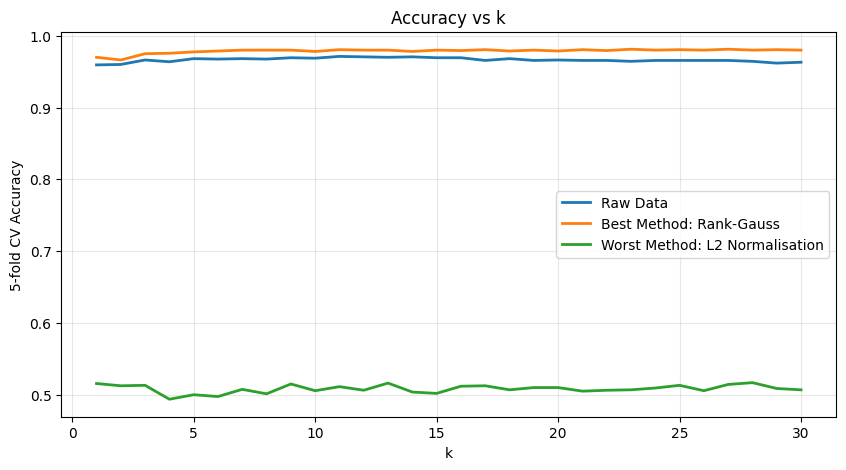

In [38]:
# Visual analysis and all the plots
feature_idx = 0
feature_name = feature_cols[feature_idx]

best_norm = methods[best_method]()
best_norm.fit(X_train)
X_test_best = best_norm.transform(X_test)

worst_norm = methods[worst_method]()
worst_norm.fit(X_train)
X_test_worst = worst_norm.transform(X_test)
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Plot histrogram of raw data on feature 1
axes[0].hist(X_test[:, feature_idx], bins=30, alpha=0.8, edgecolor='black')
axes[0].set_title('Raw Data')
axes[0].set_xlabel(feature_name)
axes[0].set_ylabel('Count')

# Plot histrogram of best method (Rank-Gauss) on feature 1
axes[1].hist(X_test_best[:, feature_idx], bins=30, alpha=0.8, edgecolor='black')
axes[1].set_title(f'Top Method: {best_method}')
axes[1].set_xlabel(feature_name)
axes[1].set_ylabel('Count')

# Plot histrogram of worst method (L2 Normalisation) on feature 1
axes[2].hist(X_test_worst[:, feature_idx], bins=30, alpha=0.8, edgecolor='black')
axes[2].set_title(f'Worst Method: {worst_method}')
axes[2].set_xlabel(feature_name)
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.show()
k_values = np.arange(1, 31)
plt.figure(figsize=(10, 5))
plt.plot(k_values, cv_curves['Raw'], label='Raw Data', linewidth=2)
plt.plot(k_values, cv_curves[best_method], label=f'Best Method: {best_method}', linewidth=2)
plt.plot(k_values, cv_curves[worst_method], label=f'Worst Method: {worst_method}', linewidth=2)
plt.xlabel('k')
plt.ylabel('5-fold CV Accuracy')
plt.title('Accuracy vs k')
plt.grid(alpha=0.3)
plt.legend()
plt.show()